In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0',
           '#00BCD4', '#795548', '#607D8B']

print("✅ All libraries loaded.")

✅ All libraries loaded.


In [4]:
df = pd.read_csv('Employee data.csv')

print("="*55)
print(f"  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("="*55)
df.head(10)

  Dataset Shape : 474 rows × 10 columns


,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No
5,6.0,Male,1958-08-22,15,Clerical,32100.0,13500.0,98.0,67.0,No
6,7.0,Male,1956-04-26,15,Clerical,36000.0,18750.0,98.0,114.0,No
7,8.0,Female,1966-05-06,12,Clerical,21900.0,9750.0,98.0,missing,No
8,9.0,Female,1946-01-23,15,Clerical,27900.0,12750.0,98.0,115.0,No
9,10.0,Female,1946-02-13,12,Clerical,24000.0,13500.0,98.0,244.0,No


In [5]:
# Column info
print("\n Column Overview:")
print("-"*55)
for col in df.columns:
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    miss  = df[col].isnull().sum()
    print(f"  {col:<25} | {str(dtype):<10} | unique={nuniq:<5} | missing={miss}")


 Column Overview:
-------------------------------------------------------
  id                        | float64    | unique=474   | missing=0
  gender                    | object     | unique=2     | missing=0
  bdate                     | object     | unique=461   | missing=1
  educ                      | int64      | unique=10    | missing=0
  jobcat                    | object     | unique=3     | missing=0
  salary                    | float64    | unique=221   | missing=0
  salbegin                  | float64    | unique=90    | missing=0
  jobtime                   | float64    | unique=36    | missing=0
  prevexp                   | object     | unique=208   | missing=0
  minority                  | object     | unique=2     | missing=0


In [6]:
# Statistical summary
print("\n Descriptive Statistics — Numerical Columns")
df.describe(percentiles=[.25, .5, .75, .90, .95]).round(2)


 Descriptive Statistics — Numerical Columns


,id,educ,salary,salbegin,jobtime
count,474.00,474.00,474.00,474.00,474.00
mean,237.50,13.49,34419.57,17016.09,81.11
std,136.98,2.88,17075.66,7870.64,10.06
min,1.00,8.00,15750.00,9000.00,63.00
25%,119.25,12.00,24000.00,12487.50,72.00
50%,237.50,12.00,28875.00,15000.00,81.00
75%,355.75,15.00,36937.50,17490.00,90.00
90%,426.70,17.00,59392.50,27501.00,94.00
95%,450.35,19.00,70000.00,33000.00,97.00
max,474.00,21.00,135000.00,79980.00,98.00


In [7]:
# Categorical summary
print("\nDescriptive Statistics — Categorical Columns")
df.describe(include='object')


Descriptive Statistics — Categorical Columns


,gender,bdate,jobcat,prevexp,minority
count,474,473,474,474,474
unique,2,461,3,208,2
top,Male,1962-07-18,Clerical,missing,No
freq,258,2,363,24,370



🔍 Missing Values:
       Missing Count  Missing %
bdate              1       0.21


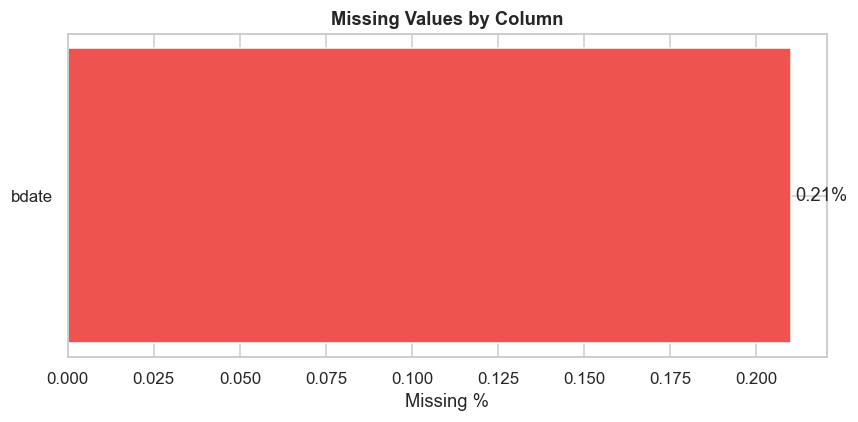

In [8]:
# ── Missing values ──────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\n🔍 Missing Values:")
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(miss_df.index, miss_df['Missing %'], color='#EF5350', edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Duplicates ──────────────────────────────────────────────
dups = df.duplicated().sum()
print(f"\n🔁 Duplicate rows: {dups}")
print(f"   Unique Employee IDs: {df['id'].nunique()} / {len(df)}")



🔁 Duplicate rows: 0
   Unique Employee IDs: 474 / 474



 Outlier Summary (IQR Method):
-------------------------------------------------------
  id                           | IQR=    236.5 | Outliers=0
  educ                         | IQR=      3.0 | Outliers=3
  salary                       | IQR=  12937.5 | Outliers=55
  salbegin                     | IQR=   5002.5 | Outliers=61
  jobtime                      | IQR=     18.0 | Outliers=0


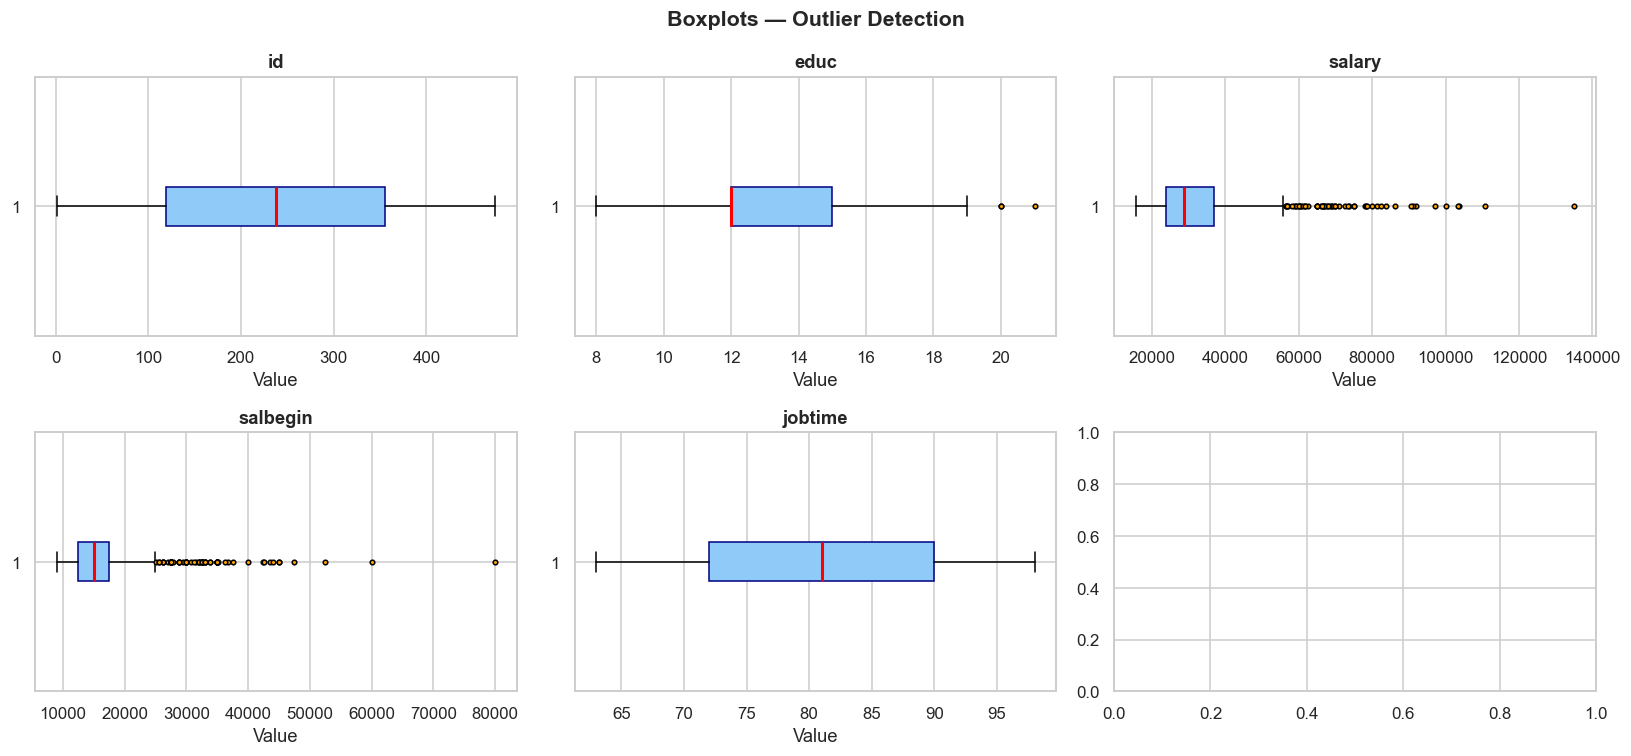

In [10]:
# ── Outlier detection via IQR ────────────────────────────────
num_cols = ['id',	'educ',	'salary',	'salbegin',	'jobtime']

print("\n Outlier Summary (IQR Method):")
print("-"*55)
outlier_counts = {}
for col in num_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    outlier_counts[col] = n_out
    print(f"  {col:<28} | IQR={IQR:>9.1f} | Outliers={n_out}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=3))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
fig.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Handle missing values ────────────────────────────────────
# Strategy: median for numeric (robust to outliers)
for col in ['educ', 'salary', 'salbegin']:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values filled with column medians.")
print(f"   Remaining nulls: {df.isnull().sum().sum()}")

Missing values filled with column medians.
   Remaining nulls: 1


In [10]:
df.isnull().sum()

id          0
gender      0
bdate       1
educ        0
jobcat      0
salary      0
salbegin    0
jobtime     0
prevexp     0
minority    0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

id          0
gender      0
bdate       0
educ        0
jobcat      0
salary      0
salbegin    0
jobtime     0
prevexp     0
minority    0
dtype: int64

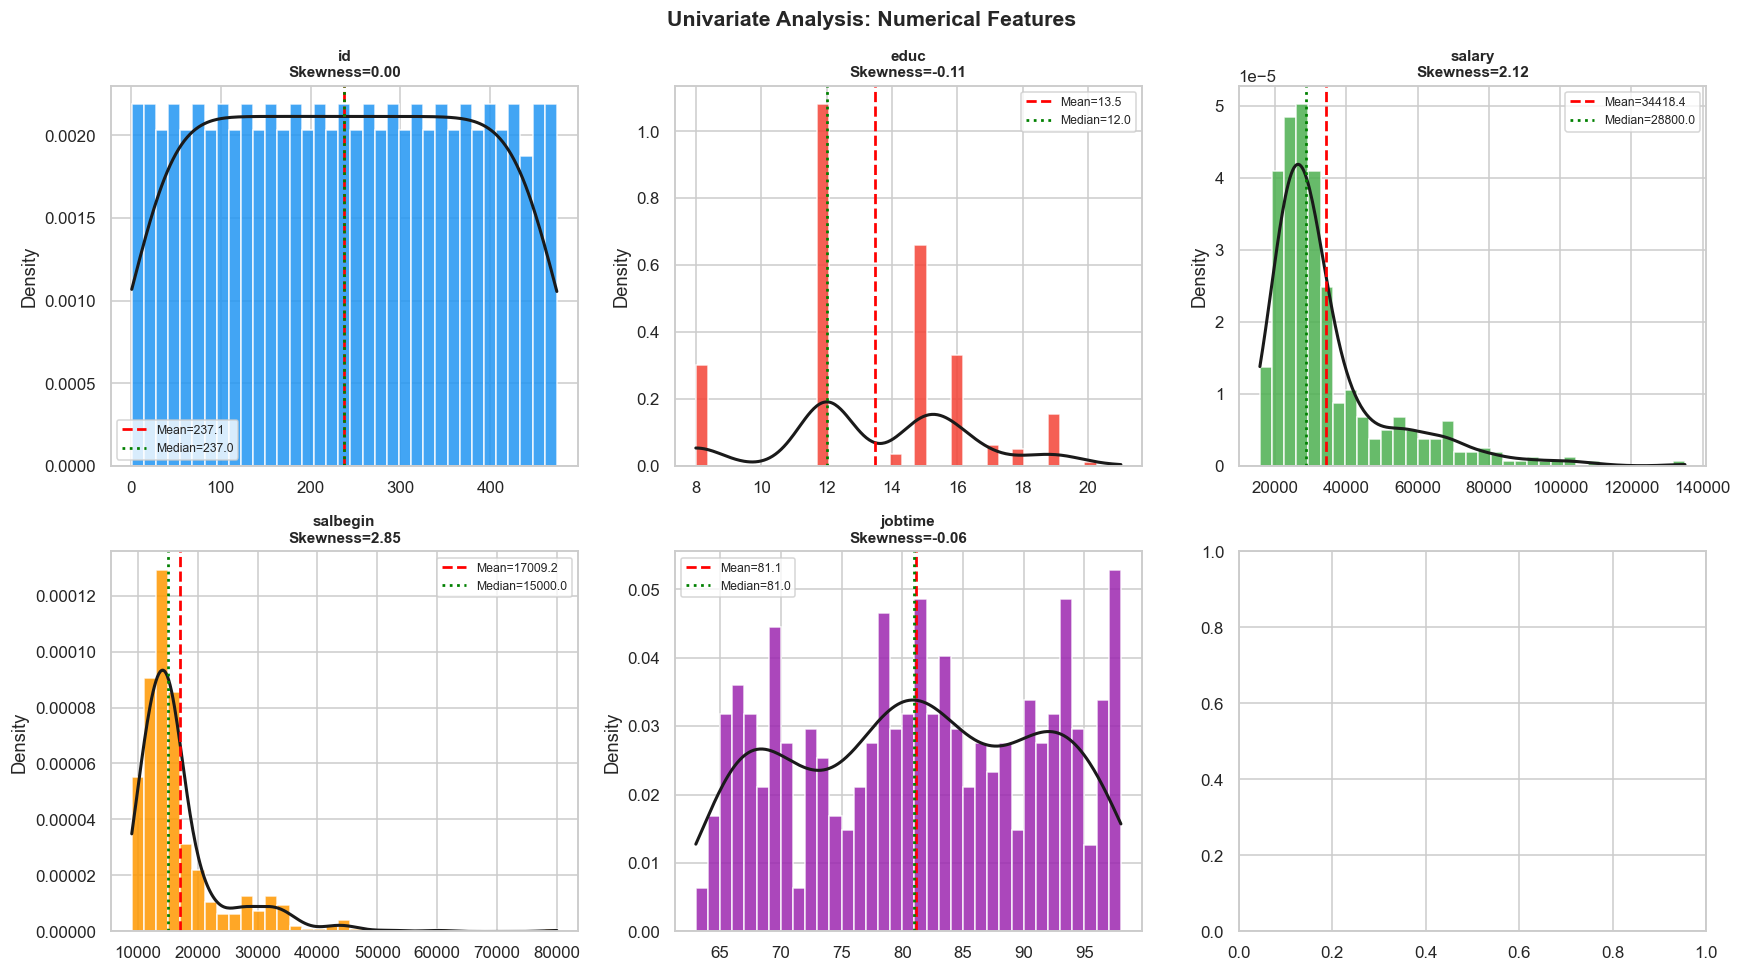

In [13]:
# ── Numerical distributions ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['id','educ','salary','salbegin','jobtime']
colors = PALETTE[:6]

for ax, col, c in zip(axes.flatten(), num_cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=35, color=c, edgecolor='white', alpha=0.85, density=True)
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, kde(x_range), 'k-', linewidth=2)
    
    mean, median = data.mean(), data.median()
    ax.axvline(mean,   color='red',   linestyle='--', linewidth=1.8, label=f'Mean={mean:.1f}')
    ax.axvline(median, color='green', linestyle=':',  linewidth=1.8, label=f'Median={median:.1f}')
    skew = data.skew()
    ax.set_title(f'{col}\nSkewness={skew:.2f}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

fig.suptitle('Univariate Analysis: Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

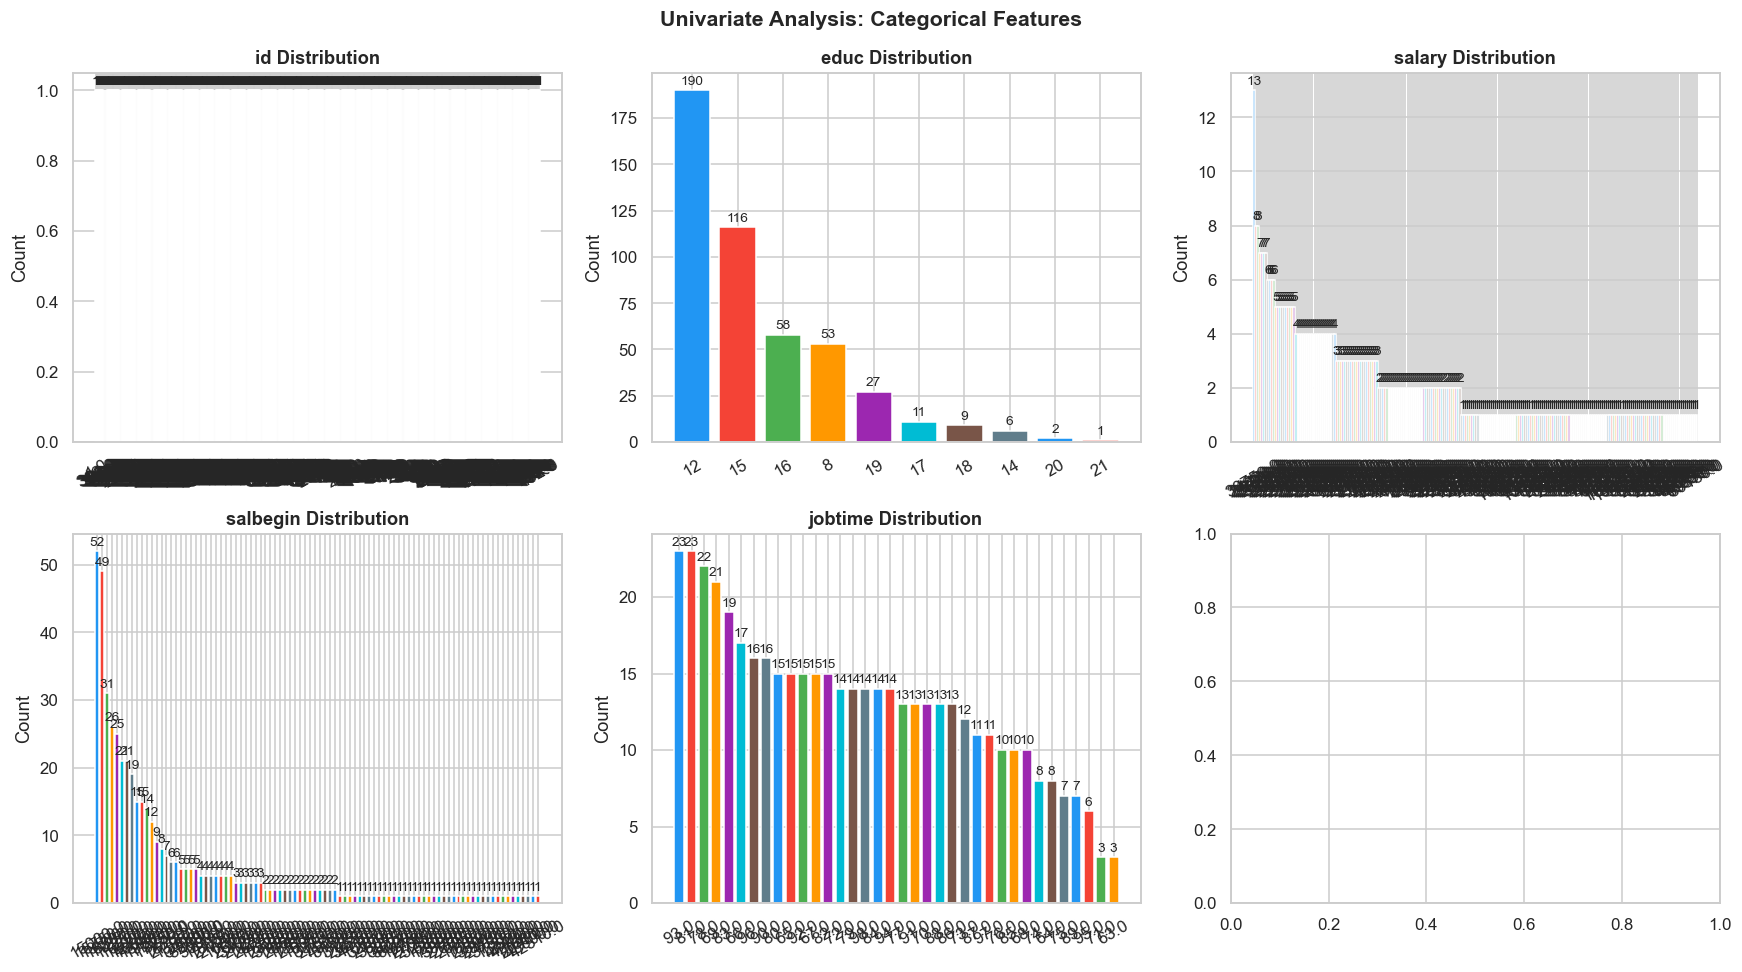

In [14]:
# ── Categorical distributions ───────────────────────────────
cat_cols = ['id','educ','salary','salbegin','jobtime']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=PALETTE[:len(vc)], edgecolor='white')
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Univariate Analysis: Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = axes[0] scatter = ax1.scatter(df['educ'], df['salary']/1e5, c=df['jobtime'], cmap='viridis', alpha=0.5, s=25) plt.colorbar(scatter, ax=ax1, label='age') # Trend line m, b, r, p, _ = stats.linregress(df['educ'], df['salary']/1e5) give me completed code xline = np.linspace(0, 40, 100) ax1.plot(xline, m*xline + b, 'r-', linewidth=2.5, label=f'R={r:.3f}') ax1.set_xlabel('educ') ax1.set_ylabel('salary (Lakhs ₹)') ax1.set_title(f'salary vs educ\n(r={r:.3f}, p={p:.2e})', fontweight='bold') ax1.legend() ax2 = axes[1]

SyntaxError: invalid syntax (1710814239.py, line 2)

NameError: name 'gaussian_kde' is not defined

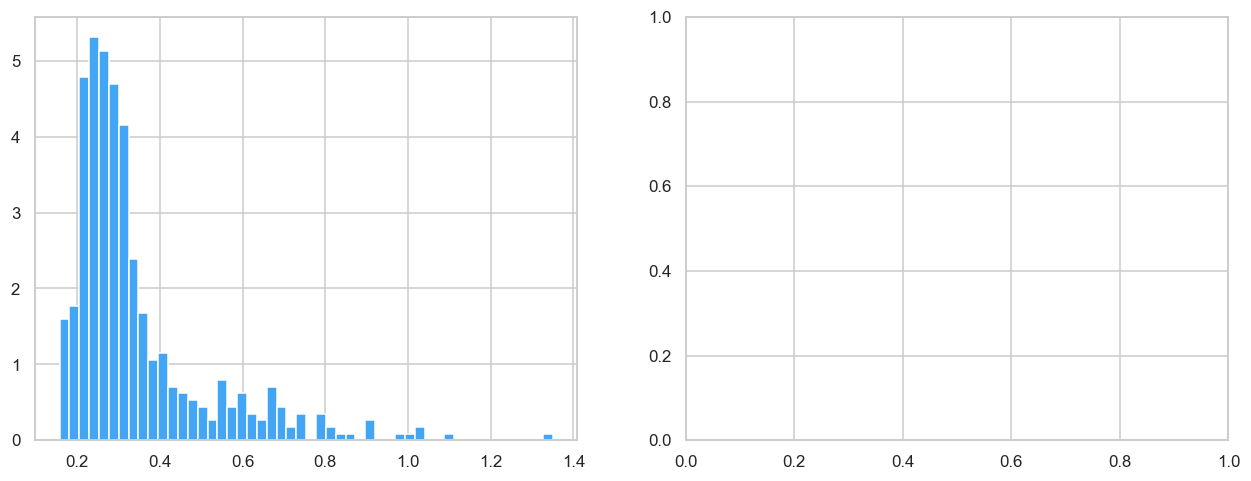

In [15]:
# ── Salary Distribution deep-dive ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
ax1 = axes[0]
ax1.hist(df['salary']/1e5, bins=50, color='#42A5F5', edgecolor='white', density=True)
kde2 = gaussian_kde(df['salary']/1e5)
xr = np.linspace(df['salary'].min()/1e5, df['salary'].max()/1e5, 400)
ax1.plot(xr, kde2(xr), 'navy', linewidth=2.5)
ax1.set_xlabel('salary (Lakhs ₹)')
ax1.set_title('salary Distribution', fontweight='bold')

# Log-transformed (normalizes skew)
ax2 = axes[1]
log_sal = np.log1p(df['salary'])
ax2.hist(log_sal, bins=50, color='#66BB6A', edgecolor='white', density=True)
kde3 = gaussian_kde(log_sal)
xr2 = np.linspace(log_sal.min(), log_sal.max(), 400)
ax2.plot(xr2, kde3(xr2), 'darkgreen', linewidth=2.5)
ax2.set_xlabel('salary)')
ax2.set_title('Log-Transformed salary (reduces skew)', fontweight='bold')

plt.suptitle('Salary Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Salary Stats (₹):")
print(f"  Min    : ₹{df['salary'].min():>12,.0f}")
print(f"  Median : ₹{df['salary'].median():>12,.0f}")
print(f"  Mean   : ₹{df['salary'].mean():>12,.0f}")
print(f"  Max    : ₹{df['salary'].max():>12,.0f}")
print(f"  Std Dev: ₹{df['salary'].std():>12,.0f}")
print(f"  Skew   : {df['salary'].skew():.3f}")

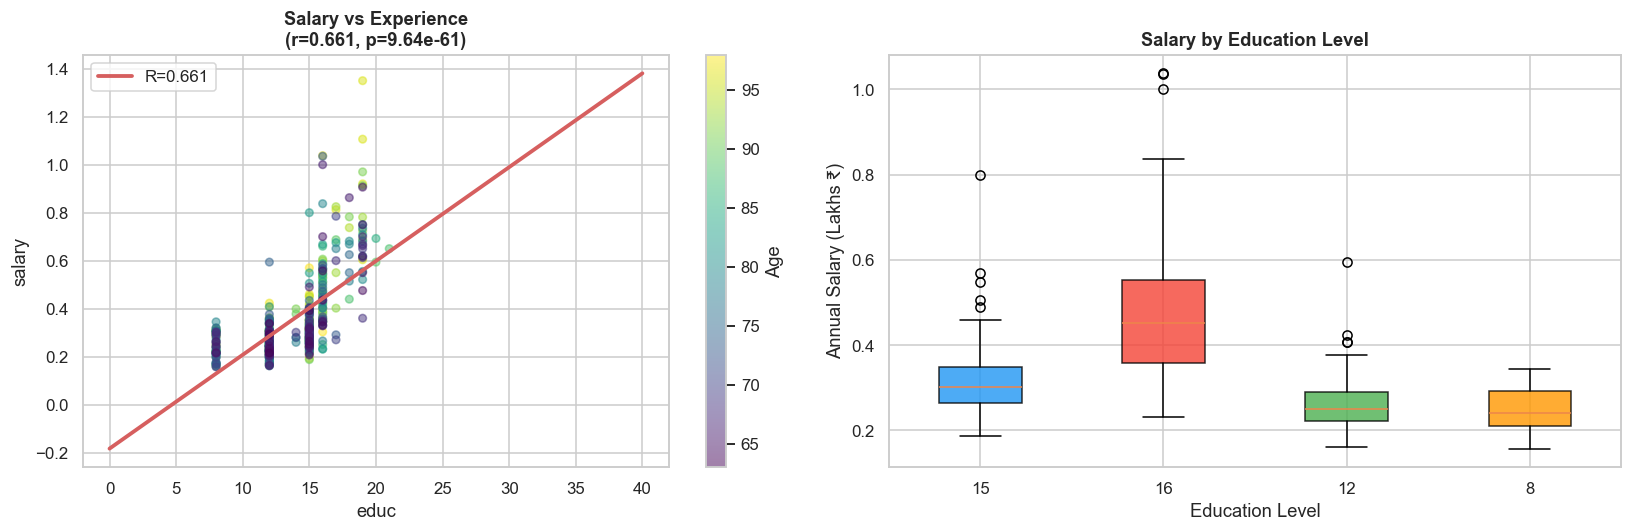

In [20]:
# ── Salary vs Experience ────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
scatter = ax1.scatter(df['educ'], df['salary']/1e5,
                      c=df['jobtime'], cmap='viridis', alpha=0.5, s=25)
plt.colorbar(scatter, ax=ax1, label='Age')
# Trend line
m, b, r, p, _ = stats.linregress(df['educ'], df['salary']/1e5)
xline = np.linspace(0, 40, 100)
ax1.plot(xline, m*xline + b, 'r-', linewidth=2.5, label=f'R={r:.3f}')
ax1.set_xlabel('educ')
ax1.set_ylabel('salary')
ax1.set_title(f'Salary vs Experience\n(r={r:.3f}, p={p:.2e})', fontweight='bold')
ax1.legend()

ax2 = axes[1]
edu_order = [15,16,12,8]
sal_by_edu = [df[df['educ']==e]['salary']/1e5 for e in edu_order]
bp = ax2.boxplot(sal_by_edu, patch_artist=True, labels= edu_order)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_xlabel('Education Level')
ax2.set_ylabel('Annual Salary (Lakhs ₹)')
ax2.set_title('Salary by Education Level', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
df

,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No
...,...,...,...,...,...,...,...,...,...,...
469,470.0,Male,1964-01-22,12,Clerical,26250.0,15750.0,64.0,69.0,Yes
470,471.0,Male,1966-08-03,15,Clerical,26400.0,15750.0,64.0,32.0,Yes
471,472.0,Male,1966-02-21,15,Clerical,39150.0,15750.0,63.0,46.0,No
472,473.0,Female,1937-11-25,12,Clerical,21450.0,12750.0,63.0,139.0,No


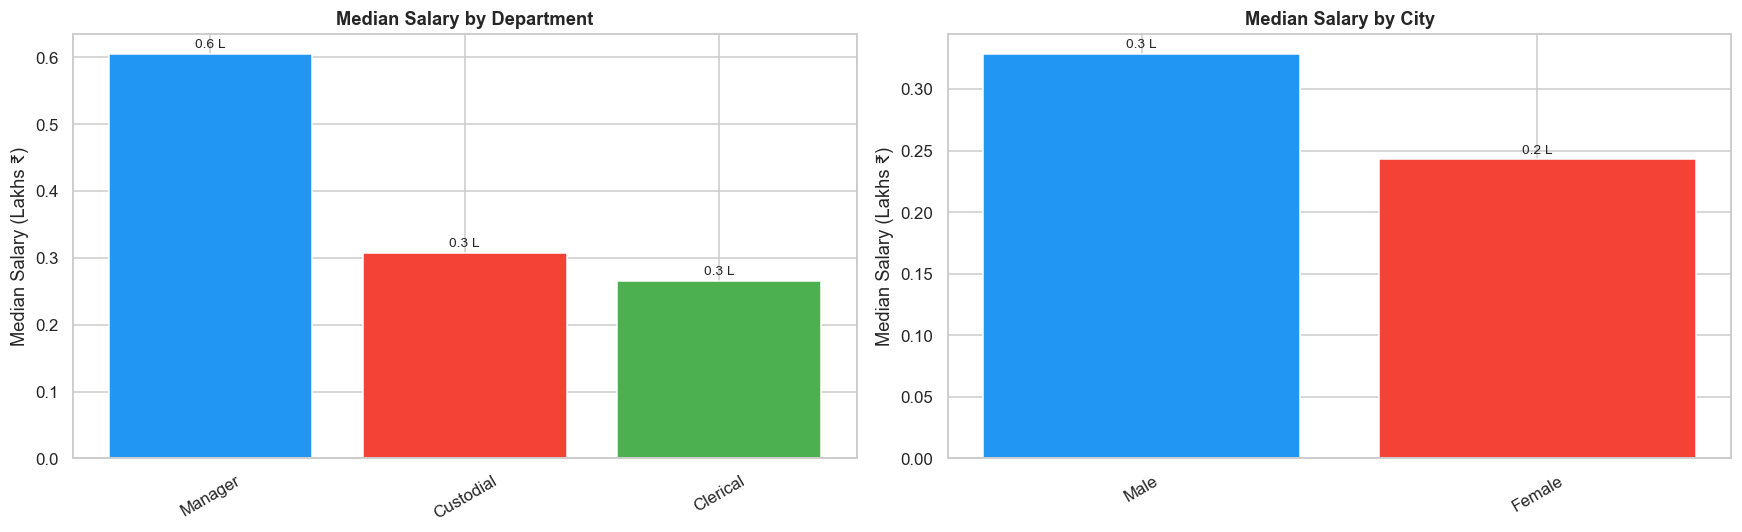

In [18]:
# ── Salary by Department & City ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Department
dept_sal = df.groupby('jobcat')['salary'].median().sort_values(ascending=False)/1e5
bars = axes[0].bar(dept_sal.index, dept_sal.values, color=PALETTE[:len(dept_sal)], edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f L', padding=2, fontsize=9)
axes[0].set_ylabel('Median Salary (Lakhs ₹)')
axes[0].set_title('Median Salary by Department', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# City
city_sal = df.groupby('gender')['salary'].median().sort_values(ascending=False)/1e5
bars2 = axes[1].bar(city_sal.index, city_sal.values, color=PALETTE[:len(city_sal)], edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f L', padding=2, fontsize=9)
axes[1].set_ylabel('Median Salary (Lakhs ₹)')
axes[1].set_title('Median Salary by City', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

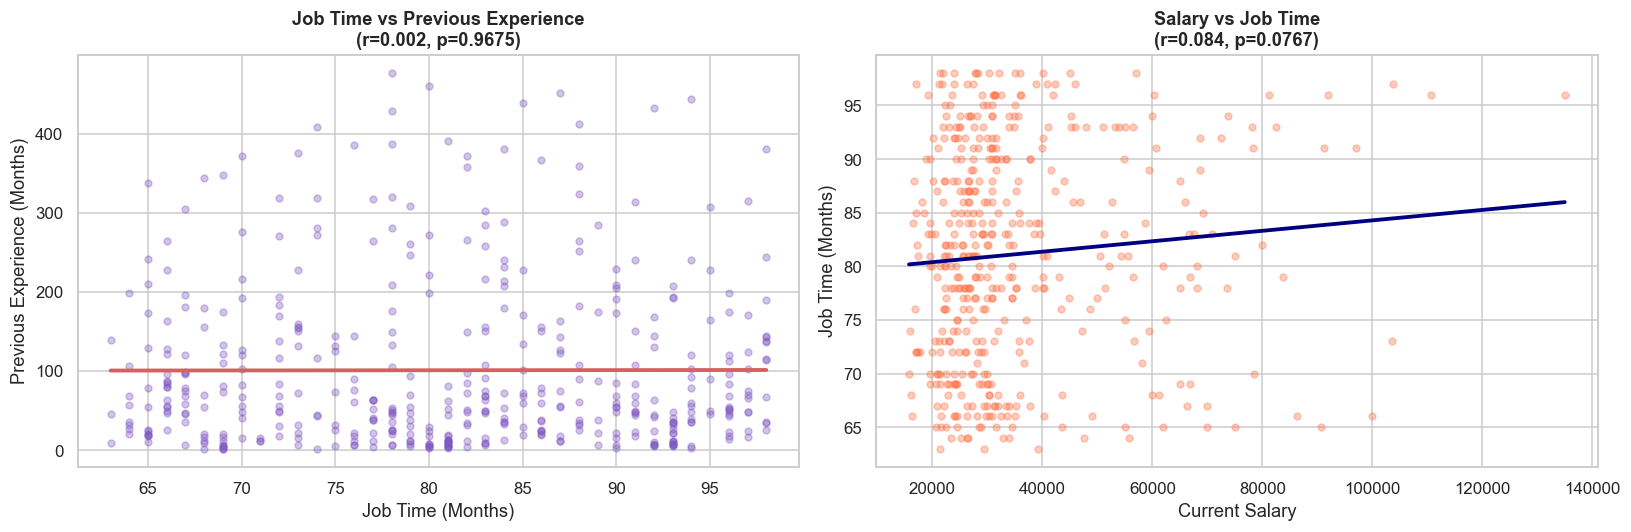

In [24]:
# ── Performance vs Satisfaction (With Numeric Conversion Fix) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['jobtime'] = pd.to_numeric(df['jobtime'], errors='coerce')
df['prevexp'] = pd.to_numeric(df['prevexp'], errors='coerce')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

df_clean = df.dropna(subset=['jobtime', 'prevexp', 'salary'])

ax1 = axes[0]
ax1.scatter(df_clean['jobtime'], df_clean['prevexp'], alpha=0.35, s=20, c='#7E57C2')

r, p = stats.pearsonr(df_clean['jobtime'], df_clean['prevexp'])
m2, b2, *_ = stats.linregress(df_clean['jobtime'], df_clean['prevexp'])

xfit = np.linspace(df_clean['jobtime'].min(), df_clean['jobtime'].max(), 100)
ax1.plot(xfit, m2*xfit + b2, 'r-', linewidth=2.5)

ax1.set_xlabel('Job Time (Months)')
ax1.set_ylabel('Previous Experience (Months)')
ax1.set_title(f'Job Time vs Previous Experience\n(r={r:.3f}, p={p:.4f})', fontweight='bold')

ax2 = axes[1]
ax2.scatter(df_clean['salary'], df_clean['jobtime'], alpha=0.35, s=20, c='#FF7043')

r2, p2 = stats.pearsonr(df_clean['salary'], df_clean['jobtime'])
m3, b3, *_ = stats.linregress(df_clean['salary'], df_clean['jobtime'])

xf2 = np.linspace(df_clean['salary'].min(), df_clean['salary'].max(), 100)
ax2.plot(xf2, m3*xf2 + b3, 'navy', linewidth=2.5)

ax2.set_xlabel('Current Salary')
ax2.set_ylabel('Job Time (Months)')
ax2.set_title(f'Salary vs Job Time\n(r={r2:.3f}, p={p2:.4f})', fontweight='bold')

plt.tight_layout()
plt.show()